In [1]:
# Cell 1: Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [2]:
# Cell 2: Đọc dữ liệu sạch
df = pd.read_csv("../data/processed/telco_churn_clean.csv")

print("Kích thước dữ liệu:", df.shape)
display(df.head())

Kích thước dữ liệu: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Cell 3: Mã hóa biến mục tiêu
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

print(df["Churn"].value_counts())
display(df.head())

Churn
0    5163
1    1869
Name: count, dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [4]:
# Cell 4: Tách X và y
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)

Kích thước X: (7032, 19)
Kích thước y: (7032,)


In [5]:
# Cell 5: Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 19)
X_test : (1407, 19)
y_train: (5625,)
y_test : (1407,)


In [6]:
# Cell 6: Xác định nhóm biến
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
categorical_features = [col for col in X.columns if col not in numerical_features]

print("Biến số:", numerical_features)
print("Biến phân loại:", categorical_features)

Biến số: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
Biến phân loại: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [7]:
# Cell 7: Preprocessor cho Random Forest
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

In [8]:
# Cell 8: Tiền xử lý dữ liệu
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()

if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape :", X_test_processed.shape)

X_train_processed shape: (5625, 30)
X_test_processed shape : (1407, 30)


In [9]:
# Cell 9: Huấn luyện Random Forest cơ bản
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

print("Huấn luyện Random Forest thành công.")

Huấn luyện Random Forest thành công.


In [10]:
# Cell 10: Dự đoán bản cơ bản
y_pred = rf_model.predict(X_test_processed)
y_prob = rf_model.predict_proba(X_test_processed)[:, 1]

print("Dự đoán xong.")

Dự đoán xong.


In [11]:
# Cell 11: Đánh giá bản cơ bản
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=== Random Forest (Basic) ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

=== Random Forest (Basic) ===
Accuracy : 0.7825
Precision: 0.6206
Recall   : 0.4679
F1-score : 0.5335
ROC-AUC  : 0.8156


In [12]:
# Cell 12: Classification Report bản cơ bản
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



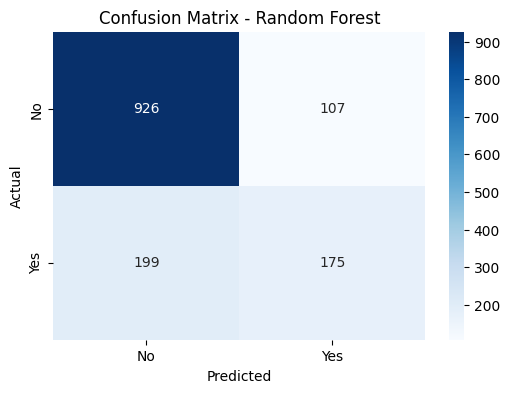

In [13]:
# Cell 13: Confusion Matrix bản cơ bản
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No", "Yes"],
            yticklabels=["No", "Yes"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

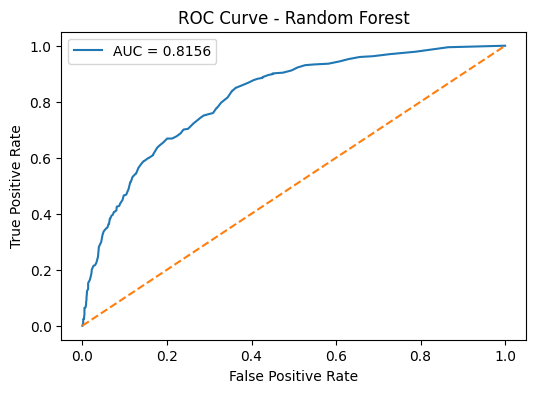

In [15]:
# Cell 14: ROC Curve bản cơ bản
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [16]:
# Cell 15: Huấn luyện Random Forest tuned
rf_model_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model_tuned.fit(X_train_processed, y_train)

print("Huấn luyện Random Forest tuned thành công.")

Huấn luyện Random Forest tuned thành công.


In [17]:
# Cell 16: Dự đoán bản tuned
y_pred_tuned = rf_model_tuned.predict(X_test_processed)
y_prob_tuned = rf_model_tuned.predict_proba(X_test_processed)[:, 1]

In [18]:
# Cell 17: Đánh giá bản tuned
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print("=== Random Forest (Tuned) ===")
print(f"Accuracy : {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall   : {recall_tuned:.4f}")
print(f"F1-score : {f1_tuned:.4f}")
print(f"ROC-AUC  : {roc_auc_tuned:.4f}")

=== Random Forest (Tuned) ===
Accuracy : 0.7584
Precision: 0.5312
Recall   : 0.7727
F1-score : 0.6296
ROC-AUC  : 0.8384


In [19]:
# Cell 18: Classification Report bản tuned
print("=== Classification Report (Tuned) ===")
print(classification_report(y_test, y_pred_tuned))

=== Classification Report (Tuned) ===
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1033
           1       0.53      0.77      0.63       374

    accuracy                           0.76      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.76      0.77      1407



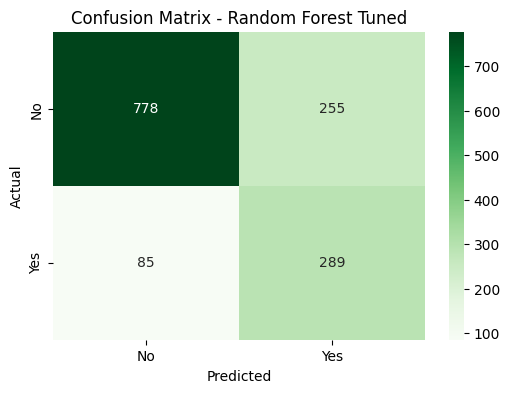

In [20]:
# Cell 19: Confusion Matrix bản tuned
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No", "Yes"],
            yticklabels=["No", "Yes"])
plt.title("Confusion Matrix - Random Forest Tuned")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

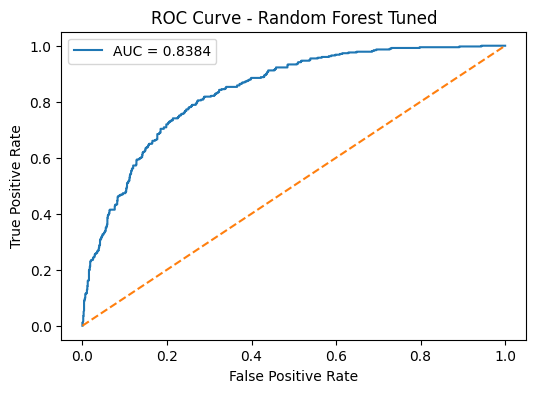

In [21]:
# Cell 20: ROC Curve bản tuned
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_tuned)

plt.figure(figsize=(6, 4))
plt.plot(fpr_tuned, tpr_tuned, label=f"AUC = {roc_auc_tuned:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Tuned")
plt.legend()
plt.show()

In [22]:
# Cell 21: Lấy tên feature
ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
encoded_cat_features = ohe.get_feature_names_out(categorical_features)

feature_names = numerical_features + list(encoded_cat_features)

print("Tổng số feature:", len(feature_names))
print(feature_names[:20])

Tổng số feature: 30
['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes']


In [23]:
# Cell 22: Feature importance
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model_tuned.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(importance_df.head(15))

,Feature,Importance
0,tenure,0.184156
2,TotalCharges,0.132370
25,Contract_Two year,0.114628
1,MonthlyCharges,0.087508
10,InternetService_Fiber optic,0.073823
28,PaymentMethod_Electronic check,0.056386
24,Contract_One year,0.046833
13,OnlineSecurity_Yes,0.034173
19,TechSupport_Yes,0.024117
16,DeviceProtection_No internet service,0.020471


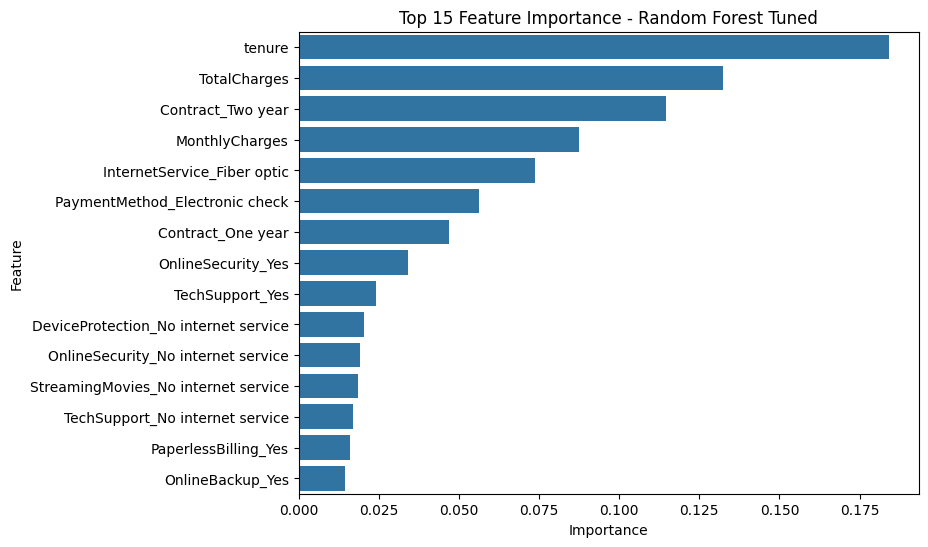

In [24]:
# Cell 23: Vẽ top feature importance
top_features = importance_df.head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top 15 Feature Importance - Random Forest Tuned")
plt.show()

In [25]:
# Cell 24: So sánh Random Forest basic và tuned
rf_results = pd.DataFrame({
    "Model": ["Random Forest Basic", "Random Forest Tuned"],
    "Accuracy": [accuracy, accuracy_tuned],
    "Precision": [precision, precision_tuned],
    "Recall": [recall, recall_tuned],
    "F1-score": [f1, f1_tuned],
    "ROC-AUC": [roc_auc, roc_auc_tuned]
})

display(rf_results)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest Basic,0.782516,0.620567,0.467914,0.533537,0.815599
1,Random Forest Tuned,0.758351,0.531250,0.772727,0.629630,0.838361


In [26]:
# Cell 25: Thử threshold khác để ưu tiên Recall
threshold = 0.4
y_pred_thresh = (y_prob_tuned >= threshold).astype(int)

accuracy_thresh = accuracy_score(y_test, y_pred_thresh)
precision_thresh = precision_score(y_test, y_pred_thresh)
recall_thresh = recall_score(y_test, y_pred_thresh)
f1_thresh = f1_score(y_test, y_pred_thresh)

print(f"=== Random Forest Tuned with threshold = {threshold} ===")
print(f"Accuracy : {accuracy_thresh:.4f}")
print(f"Precision: {precision_thresh:.4f}")
print(f"Recall   : {recall_thresh:.4f}")
print(f"F1-score : {f1_thresh:.4f}")
print(f"ROC-AUC  : {roc_auc_tuned:.4f}")

=== Random Forest Tuned with threshold = 0.4 ===
Accuracy : 0.7129
Precision: 0.4773
Recall   : 0.8449
F1-score : 0.6100
ROC-AUC  : 0.8384


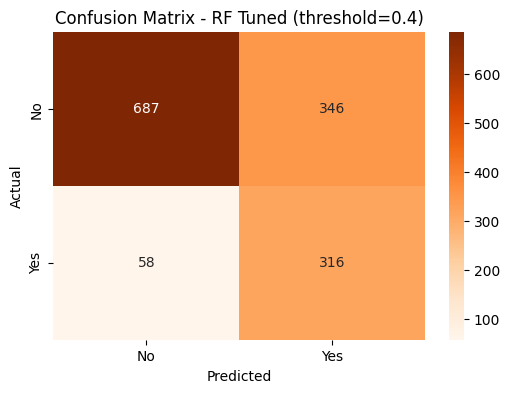

In [27]:
# Cell 26: Confusion Matrix với threshold mới
cm_thresh = confusion_matrix(y_test, y_pred_thresh)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_thresh, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["No", "Yes"],
            yticklabels=["No", "Yes"])
plt.title(f"Confusion Matrix - RF Tuned (threshold={threshold})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()